<a href="https://colab.research.google.com/github/santana-robledo/Posgrado_Robotica_e_Inteligencia_Artificial/blob/main/Sistemas%20Inteligentes%20II/Loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Josue Santana Robledo Corona

In [98]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [99]:
!wget https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/loan_prediction.csv

--2026-03-09 18:40:48--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/loan_prediction.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17516 (17K) [text/plain]
Saving to: ‘loan_prediction.csv.4’

loan_prediction.csv 100%[===================>]  17.11K  --.-KB/s    in 0s      

2026-03-09 18:40:48 (136 MB/s) - ‘loan_prediction.csv.4’ saved [17516/17516]



In [100]:
dataset=pd.read_csv('loan_prediction.csv')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    614 non-null    int64  
 1   CoapplicantIncome  614 non-null    float64
 2   LoanAmount         614 non-null    float64
 3   Loan_Amount_Term   614 non-null    float64
 4   Credit_History     614 non-null    float64
 5   Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 28.9 KB


In [101]:
dataset.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,5849,0.0,0.0,360.0,1.0,1
1,4583,1508.0,128.0,360.0,1.0,0
2,3000,0.0,66.0,360.0,1.0,1
3,2583,2358.0,120.0,360.0,1.0,1
4,6000,0.0,141.0,360.0,1.0,1


In [102]:
dataset.isin(['?', 'NA', 'N/A', '-']).sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Loan_Status,0


In [103]:
dataset.isna().sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Loan_Status,0


In [104]:
dataset.isnull().sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Loan_Status,0


In [105]:
print(dataset.columns)

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status'],
      dtype='object')


In [106]:
dataset = pd.get_dummies(dataset, drop_first=True)

In [107]:
dataset['Loan_Status'].unique()

array([1, 0])

In [108]:
dataset.dtypes

,0
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64
Loan_Status,int64


In [109]:
dataset['Credit_History'] = dataset['Credit_History'].astype(float)

In [110]:
x = np.asanyarray(dataset[['ApplicantIncome','Credit_History']])
y = dataset['Loan_Status'].values

x = StandardScaler().fit_transform(x)

print(x.shape)
print(y.shape)

(614, 2)
(614,)


In [111]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2,stratify=y)

In [112]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(8, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dropout(0.3))
  model.add(keras.layers.Dense(8, activation='relu'))
  model.add(keras.layers.Dense(1, activation='sigmoid'))

  model.compile(
      loss='binary_crossentropy',
      optimizer=keras.optimizers.Adam(0.02),
      metrics=['accuracy']
  )

  return model

In [113]:
model = build_model()
model.summary()

result = model.evaluate(xtest, ytest)
print(result)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6556 - loss: 0.6962  
[0.6866583824157715, 0.6910569071769714]


In [114]:
def plot_history(history):

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train','validation'])
    plt.show()

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train','validation'])
    plt.show()

In [115]:
history = model.fit(xtrain, ytrain,
                    batch_size=100, epochs=400,
                    validation_data=(xtest, ytest), verbose=1)



Epoch 1/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6416 - loss: 0.6655 - val_accuracy: 0.6911 - val_loss: 0.6008
Epoch 2/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6939 - loss: 0.6135 - val_accuracy: 0.7073 - val_loss: 0.5639
Epoch 3/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7129 - loss: 0.5819 - val_accuracy: 0.7480 - val_loss: 0.5428
Epoch 4/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7546 - loss: 0.5785 - val_accuracy: 0.7480 - val_loss: 0.5478
Epoch 5/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7867 - loss: 0.5233 - val_accuracy: 0.7561 - val_loss: 0.5506
Epoch 6/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7641 - loss: 0.5387 - val_accuracy: 0.7561 - val_loss: 0.5508
Epoch 7/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7717 - loss: 0.5379 - val_accuracy: 0.7561 - val_loss: 0.5526
Epoch 8/400
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7887 - loss: 0.5224 - val_accuracy: 0.7561 - val_loss:

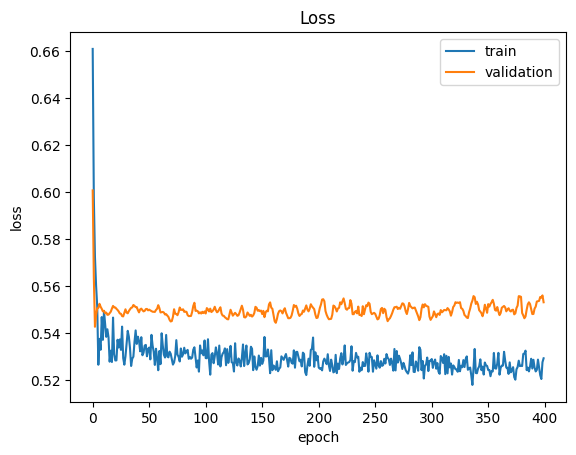

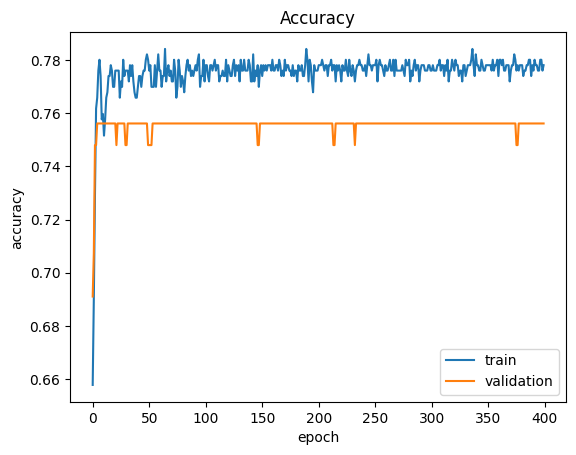

In [116]:
plot_history(history)

In [117]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [118]:
gist_df=pd.DataFrame(history.history)
##gist_df.to_csv('history.csv',index=False)
print(gist_df)

     accuracy      loss  val_accuracy  val_loss
0    0.657841  0.660969      0.691057  0.600809
1    0.690428  0.597703      0.707317  0.563891
2    0.729124  0.572513      0.747967  0.542812
3    0.761711  0.560339      0.747967  0.547777
4    0.765784  0.551486      0.756098  0.550624
..        ...       ...           ...       ...
395  0.775967  0.525655      0.756098  0.553831
396  0.780041  0.522241      0.756098  0.555472
397  0.780041  0.520594      0.756098  0.555151
398  0.775967  0.527755      0.756098  0.556156
399  0.778004  0.529413      0.756098  0.553239

[400 rows x 4 columns]


In [119]:
result = model.evaluate(xtest, ytest)
print(result)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7462 - loss: 0.5690 
[0.5532395243644714, 0.7560975551605225]
